In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import pickle
from lib.paths import Paths

# File manipulation

In [2]:
def get_mean_var(ide):
    
    file_path = os.path.join(Paths.short_data, str(ide))
    with open(file_path, "rb") as f:
        res = pickle.load(f)

    data = res["data"][:100, -1, :]
    return (np.mean(data, axis=0), np.var(data, axis=0))

In [3]:
df = pd.read_csv("./catalog.csv")

In [4]:
ides = df["id"].values

In [11]:
new = ides[ides>34]

In [12]:
new

array([35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 51, 52, 53,
       54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65])

In [13]:
def save_mean_var(ide):
    dest = os.path.join(Paths.mean_var, str(ide))

    mean, var = get_mean_var(ide)

    with open(dest, "wb") as f:
        pickle.dump(
            {"mean":mean, "var":var}, f
        )

    

In [10]:
save_mean_var(34)

In [14]:
for ide in new:
    save_mean_var(ide)


# PLOTS

In [27]:
exclusion = df[(df["exclusion"]==True)&(df["cooperativity"]==False)]
co_exclusion = df[(df["exclusion"]==True)&(df["cooperativity"]==True)]
no_exclusion = df[(df["exclusion"]==False)&(df["cooperativity"]==False)]
co_no_exclusion = df[(df["exclusion"]==False)&(df["cooperativity"]==True)]

In [36]:
ides = {"exclusion":exclusion["id"].values, 
        "no_exclusion":no_exclusion["id"].values, 
        "co_exclusion":co_exclusion["id"].values,
          "co_no_exclusion":co_no_exclusion["id"].values}
    
    

In [21]:
ides

array([34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48])

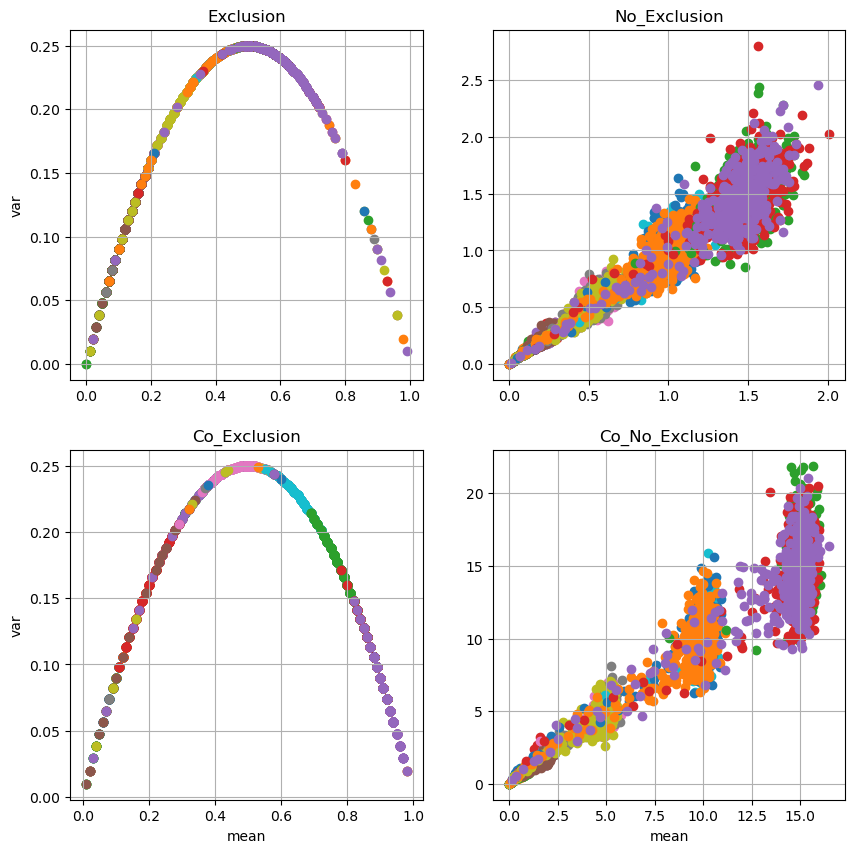

In [42]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize = (10,10))

for ide in ides["exclusion"]:
    with open(os.path.join(Paths.mean_var, str(ide)), "rb") as f:
        res = pickle.load(f)
    ax3.scatter(res["mean"], res["var"])

for ide in ides["no_exclusion"]:
    with open(os.path.join(Paths.mean_var, str(ide)), "rb") as f:
        res = pickle.load(f)
    ax4.scatter(res["mean"], res["var"])

for ide in ides["co_exclusion"]:
    with open(os.path.join(Paths.mean_var, str(ide)), "rb") as f:
        res = pickle.load(f)
    ax1.scatter(res["mean"], res["var"])

for ide in ides["co_no_exclusion"]:
    with open(os.path.join(Paths.mean_var, str(ide)), "rb") as f:
        res = pickle.load(f)
    ax2.scatter(res["mean"], res["var"])

ax1.set(title="Exclusion", ylabel="var")
ax2.set(title="No_Exclusion")
ax3.set(title="Co_Exclusion", xlabel="mean", ylabel="var")
ax4.set(title="Co_No_Exclusion", xlabel="mean")

ax1.grid()
ax2.grid()
ax3.grid()
ax4.grid()

In [41]:
fig.savefig('mean_var.png', dpi=300)

In [23]:
with open(os.path.join(Paths.mean_var, str(34)), "rb") as f:
        res = pickle.load(f)

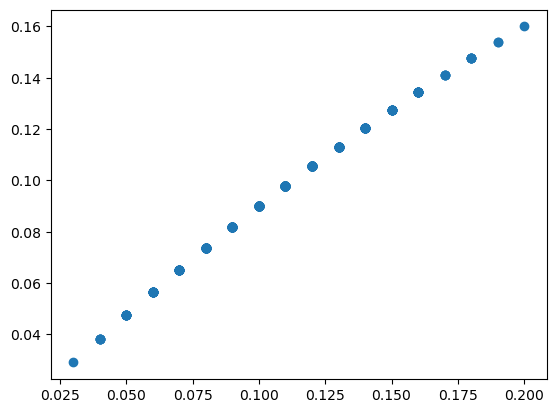

In [24]:
plt.scatter(res["mean"], res["var"])